# Context

**Dataset:** Hillstrom / MineThatData email challenge (64,000 customers), loaded via `sklift.datasets.fetch_hillstrom`.

**Design:** A randomized experiment with three arms — 1/3 Mens E-Mail, 1/3 Womens E-Mail, 1/3 No E-Mail (control). The outcome used here is `visit`: 1 if the customer visited the website in the two weeks following the campaign.

**Project framing:** The goal of this project is to learn from a past campaign — the Hillstrom experiment — in order to inform who should receive the next one. The question is not whether the campaign worked overall, which a difference in means can answer. It's which customers the email actually moves, so that future sends can be targeted rather than blanket.
That breaks into three stages:

1. **Validate the data** — quality checks, and confirm the randomization actually balanced the arms, since everything downstream depends on it.
2. **Model the heterogeneity** — train an uplift model to estimate customer-level treatment effects and surface the pattern of who responds.
3. **Translate to a recommendation** — who to target next time, and what that decision is worth.


In [1]:
import pandas as pd
import numpy as np
from sklift.datasets import fetch_hillstrom

pd.set_option('display.max_columns', None)

/Users/chunliu/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## EDA

In [2]:
bunch = fetch_hillstrom(target_col='visit')

df = bunch.data.copy()
df['segment'] = bunch.treatment
df['visit'] = bunch.target

print(df.shape)
df.head()

(64000, 10)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0


In [3]:
df.dtypes

recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
dtype: object

In [4]:
df.isna().sum()

recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
dtype: int64

In [5]:
df['channel'].value_counts()

channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64

In [6]:
df = df.reset_index().rename(columns={'index': 'customer_id'})

In [7]:
df.head()

,customer_id,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit
0,0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0
1,1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0
2,2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0
3,3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0
4,4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0


### Arm sizes

In [8]:
df['segment'].value_counts()

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

### Collapse to two-arm treatment indicator

the main analysis collapses Mens E-Mail + Womens E-Mail into a single `treatment = 1` ("any email") vs. `treatment = 0` ("No E-Mail").

In [9]:
df['treatment'] = (df['segment'] != 'No E-Mail').astype(int)
df['treatment'].value_counts()

treatment
1    42694
0    21306
Name: count, dtype: int64

### Randomization balance check

This is the core sanity check for this notebook: if randomization worked, the two arms (`treatment` 0 vs. 1) should look statistically indistinguishable on every *pre-treatment* covariate — recency, history, mens/womens purchase history, channel, zip/urban-rural, and newbie status. Any imbalance here is a real RCT-integrity flag (not necessarily fatal, but it must be surfaced), not something to explain away silently.

**Handed off to you from here on** — EDA, the balance tests themselves (what test fits a continuous covariate vs. a categorical one, and why), interpretation, and everything downstream (baseline model, uplift model, evaluation, profit curve, write-up).

In [10]:
df.head()

,customer_id,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,treatment
0,0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,1
1,1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0
2,2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,1
3,3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,1
4,4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,1


In [11]:
# randomization check
from scipy import stats

continuous_vars = ['recency', 'history']
binary_vars = ['mens', 'womens', 'newbie']
categorical_vars = ['channel', 'zip_code', 'history_segment']

res= []

for col in continuous_vars:
    treated = df.loc[df['treatment'] == 1, col]
    control = df.loc[df['treatment'] == 0, col]
    t_stat, pval = stats.ttest_ind(treated, control, equal_var=False)
    res.append(
        {
            'covariate': col,
            'test': 'Welch t-test', 
            'Statistic': t_stat,
            'p value': pval
        }
    )

for col in binary_vars + categorical_vars:
    contingency = pd.crosstab(df[col], df['treatment'])
    stat, p, dof, expected = stats.chi2_contingency(contingency)
    res.append(
            {
                'covariate': col,
                'test': 'chi-square', 
                'Statistic': stat,
                'p value': p
            }
    )

table = pd.DataFrame(res).round(3)

# testing 8 covariates at once inflats the false-positive rate; Bonferroni-adjust the threshold
alpha = 0.05 / len(table)
table['imbalanced'] = table['p value'] < alpha
table


,covariate,test,Statistic,p value,imbalanced
0,recency,Welch t-test,0.716,0.474,False
1,history,Welch t-test,0.845,0.398,False
2,mens,chi-square,0.608,0.436,False
3,womens,chi-square,0.545,0.460,False
4,newbie,chi-square,0.008,0.927,False
5,channel,chi-square,0.348,0.840,False
6,zip_code,chi-square,1.257,0.533,False
7,history_segment,chi-square,5.310,0.505,False


### Outcome variable

In [12]:
bunch_all = fetch_hillstrom(target_col='all')
df['conversion'] = bunch_all.target['conversion']

In [13]:
# 1. overall and control baseline rates, visits vs conversion side by side
baseline = pd.DataFrame({
    'overall_rate': df[['visit', 'conversion']].mean(),
    'control_rate': df.loc[df['treatment'] == 0, ['visit', 'conversion']].mean()
})

baseline

,overall_rate,control_rate
visit,0.146781,0.106167
conversion,0.009031,0.005726


In [14]:
# 2. rate by original 3-arm segment (before collapsing to treatment/control)
segment_rates = df.groupby('segment')['visit'].mean().sort_values(ascending=False)
segment_rates

segment
Mens E-Mail      0.182757
Womens E-Mail    0.151400
No E-Mail        0.106167
Name: visit, dtype: float64

In [15]:
# 3. dirty value check, visit/conversion should only ever be {0,1}
print("clean:", df['visit'].isin([0,1]).all() and df['conversion'].isin([0,1]).all())

clean: True


### Overall ATE

In [16]:
treated_rate = df.loc[df['treatment'] == 1, 'visit'].mean()
control_rate = df.loc[df['treatment'] == 0, 'visit'].mean()

overall_ate = pd.DataFrame({
    'treated': [treated_rate],
    'control': [control_rate],
    'diff': [treated_rate - control_rate],
})

overall_ate

,treated,control,diff
0,0.167049,0.106167,0.060882


In [17]:
def lift_by_group(df, group_col, outcome='visit', treatment_col='treatment'):
    stats = (
        df.groupby([group_col, treatment_col])[outcome]
        .agg(['mean', 'count'])
        .unstack(treatment_col)
    )
    stats.columns = [f'{stat}_{"treated" if t == 1 else "control"}' for stat, t in stats.columns]
    stats['lift'] = stats['mean_treated'] - stats['mean_control']
    return stats[['mean_control', 'mean_treated', 'lift', 'count_control', 'count_treated']]

continuous_vars = ['recency', 'history']
categorical_vars = ['history_segment', 'mens', 'womens', 'zip_code', 'newbie', 'channel']

for col in continuous_vars:
    bucket_col = f'{col}_bucket'
    df[bucket_col] = pd.qcut(df[col], q=4, duplicates='drop')
    print(f"--- {col} ---")
    display(lift_by_group(df, bucket_col))

--- recency ---


/var/folders/5k/pp7drsgs4n94h8hr9dg0l2880000gn/T/ipykernel_54542/3254296063.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([group_col, treatment_col])[outcome]


,mean_control,mean_treated,lift,count_control,count_treated
recency_bucket,,,,,
"(0.999, 2.0]",0.141948,0.208155,0.066207,5502,10987
"(2.0, 6.0]",0.111608,0.170225,0.058617,6702,13394
"(6.0, 9.0]",0.081932,0.144069,0.062136,4699,9315
"(9.0, 12.0]",0.079037,0.135919,0.056882,4403,8998


--- history ---


/var/folders/5k/pp7drsgs4n94h8hr9dg0l2880000gn/T/ipykernel_54542/3254296063.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([group_col, treatment_col])[outcome]


,mean_control,mean_treated,lift,count_control,count_treated
history_bucket,,,,,
"(29.988999999999997, 64.66]",0.084707,0.141445,0.056738,5277,10725
"(64.66, 158.11]",0.083854,0.142221,0.058367,5438,10561
"(158.11, 325.657]",0.119924,0.178209,0.058284,5270,10729
"(325.657, 3345.93]",0.136628,0.206105,0.069477,5321,10679


In [18]:
for col in categorical_vars:
    print(f"--- {col} ---")
    display(lift_by_group(df, col))

--- history_segment ---


,mean_control,mean_treated,lift,count_control,count_treated
history_segment,,,,,
1) $0 - $100,0.084866,0.142597,0.057731,7612,15358
2) $100 - $200,0.090984,0.146740,0.055756,4836,9418
3) $200 - $350,0.126360,0.186416,0.060056,4044,8245
4) $350 - $500,0.150188,0.214469,0.064281,2124,4285
5) $500 - $750,0.109564,0.191777,0.082212,1652,3259
"6) $750 - $1,000",0.154341,0.212611,0.058270,622,1237
"7) $1,000 +",0.165865,0.242152,0.076287,416,892


--- mens ---


,mean_control,mean_treated,lift,count_control,count_treated
mens,,,,,
0,0.095808,0.168098,0.072289,9519,19215
1,0.114533,0.166191,0.051658,11787,23479


--- womens ---


...

,mean_control,mean_treated,lift,count_control,count_treated
zip_code,,,,,
Rural,0.153552,0.205012,0.051460,3139,6424
Surburban,0.099013,0.160514,0.061501,9625,19151
Urban,0.096816,0.160114,0.063299,8542,17119


--- newbie ---


,mean_control,mean_treated,lift,count_control,count_treated
newbie,,,,,
0,0.133729,0.192704,0.058975,10611,21245
1,0.078822,0.141638,0.062816,10695,21449


--- channel ---


,mean_control,mean_treated,lift,count_control,count_treated
channel,,,,,
Multichannel,0.128550,0.193561,0.065011,2606,5156
Phone,0.087166,0.147106,0.059940,9327,18694
Web,0.118852,0.179580,0.060728,9373,18844


### Train/Test Split

In [19]:
from sklearn.model_selection import train_test_split

stratify_key = df['treatment'].astype(str) + '_' + df['visit'].astype(str)

train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    stratify=stratify_key,
    random_state=42
)

print(f"train: {train_df.shape}, test: {test_df.shape}")
print(train_df.groupby(['treatment', 'visit']).size() / len(train_df))
print(test_df.groupby(['treatment', 'visit']).size() / len(test_df))

train: (44800, 15), test: (19200, 15)
treatment  visit
0          0        0.297567
           1        0.035357
1          0        0.555647
           1        0.111429
dtype: float64
treatment  visit
0          0        0.297552
           1        0.035312
1          0        0.555677
           1        0.111458
dtype: float64


### Feature Engineering

In [29]:
# Define the feature set

# Features known before the send decision.
# Drop: customer_id (row label), segment/treatment (target of the decision itself),
# visit/conversion (outcomes — leakage), recency_bucket/history_bucket (EDA-only,
# redundant with recency/history), history_segment (redundant with history).

numeric_features = ['recency', 'history']
binary_features = ['mens', 'womens', 'newbie']
categorical_features = ['zip_code', 'channel']

feature_cols = numeric_features + binary_features + categorical_features

In [30]:
# one-hot encode, fit on train only

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)

preprocessor.fit(train_df[feature_cols])

/Users/chunliu/Library/Python/3.9/lib/python/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['zip_code', 'channel']),
                                ('num', StandardScaler(),
                                 ['recency', 'history'])])

In [31]:
# Transform both sets into arrays

X_train_arr = preprocessor.transform(train_df[feature_cols])
X_test_arr = preprocessor.transform(test_df[feature_cols])

feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(X_train_arr, columns=feature_names, index=train_df.index)
X_test = pd.DataFrame(X_test_arr, columns=feature_names, index=test_df.index)

X_train.head()

,cat__zip_code_Surburban,cat__zip_code_Urban,cat__channel_Phone,cat__channel_Web,num__recency,num__history,remainder__mens,remainder__womens,remainder__newbie
25453,0.0,1.0,0.0,0.0,-1.070533,0.626747,1.0,1.0,1.0
12800,1.0,0.0,0.0,1.0,0.068163,-0.462955,0.0,1.0,1.0
2290,0.0,1.0,0.0,1.0,-0.501185,-0.188088,0.0,1.0,0.0
31961,1.0,0.0,0.0,1.0,0.637511,0.069545,1.0,0.0,0.0
19324,1.0,0.0,1.0,0.0,1.206859,0.115720,1.0,0.0,1.0


In [32]:
treatment_train, treatment_test = train_df['treatment'], test_df['treatment']
y_train, y_test = train_df['visit'], test_df['visit']

print(X_train.shape, X_test.shape)
print(feature_names)

(44800, 9) (19200, 9)
['cat__zip_code_Surburban' 'cat__zip_code_Urban' 'cat__channel_Phone'
 'cat__channel_Web' 'num__recency' 'num__history' 'remainder__mens'
 'remainder__womens' 'remainder__newbie']


### Does tree based model beat linear?

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for arm_name, arm_value in [('control', 0), ('treated', 1)]:
    mask = treatment_train == arm_value
    X_arm = X_train[mask]
    y_arm = y_train[mask]

    for model_name, model in [
        ('logistic', LogisticRegression(max_iter=1000)),
        ('random_forest', RandomForestClassifier(n_estimators=200, random_state=42)),
    ]:
        scores = cross_val_score(model, X_arm, y_arm, cv=cv, scoring='roc_auc')
        results.append({
            'arm': arm_name,
            'model': model_name,
            'mean_auc': scores.mean(),
            'std_auc': scores.std()
        })

pd.DataFrame(results)

,arm,model,mean_auc,std_auc
0,control,logistic,0.646586,0.027949
1,control,random_forest,0.568921,0.014568
2,treated,logistic,0.620211,0.008975
3,treated,random_forest,0.538694,0.011150


### T Learner

In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

models = {}

for arm_name, arm_value in [('control', 0), ('treated', 1)]:
    mask = treatment_train == arm_value
    X_arm = X_train[mask]
    y_arm = y_train[mask]

    search = GridSearchCV(
        LogisticRegression(max_iter=1000),
        param_grid,
        scoring='roc_auc',
        cv=cv,
        refit=True,  # refits on the full arm's data using the best C found
    )
    search.fit(X_arm, y_arm)

    models[arm_name] = search.best_estimator_
    print(f"{arm_name}: best C = {search.best_params_['C']}, best CV AUC = {search.best_score_:.4f}")

control: best C = 100, best CV AUC = 0.6466
treated: best C = 100, best CV AUC = 0.6202


In [38]:
# score every test-set customer with BOTH arm models
mu1_test = models['treated'].predict_proba(X_test)[:, 1]
mu0_test = models['control'].predict_proba(X_test)[:, 1]

uplift_test = mu1_test - mu0_test

pd.Series(uplift_test).describe()

count    19200.000000
mean         0.060079
std          0.019487
min         -0.023885
25%          0.043478
50%          0.060629
75%          0.075760
max          0.109813
dtype: float64

### Qini and AUUC

Qini AUC: 0.0520
Uplift AUC (AUUC): 0.0309


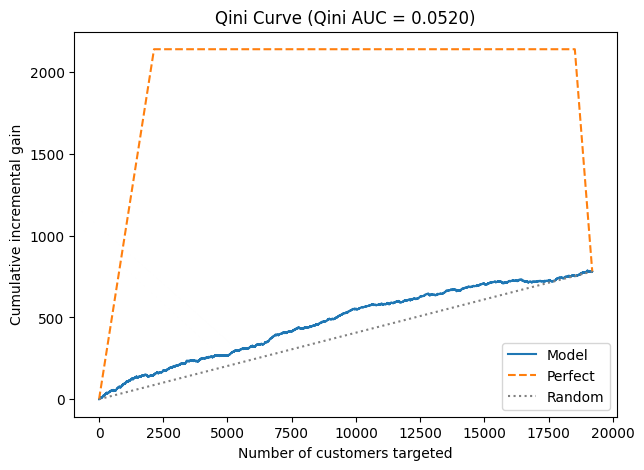

In [40]:
from sklift.metrics import qini_auc_score, uplift_auc_score, qini_curve, perfect_qini_curve
import matplotlib.pyplot as plt

# scores
qini_score = qini_auc_score(y_true=y_test, uplift=uplift_test, treatment=treatment_test)
auuc_score = uplift_auc_score(y_true=y_test, uplift=uplift_test, treatment=treatment_test)

print(f"Qini AUC: {qini_score:.4f}")
print(f"Uplift AUC (AUUC): {auuc_score:.4f}")

# curve data (avoids sklift.viz, which is broken under this sklearn version)
x_qini, y_qini = qini_curve(y_true=y_test, uplift=uplift_test, treatment=treatment_test)
x_perfect, y_perfect = perfect_qini_curve(y_true=y_test, treatment=treatment_test)

plt.figure(figsize=(7, 5))
plt.plot(x_qini, y_qini, label='Model')
plt.plot(x_perfect, y_perfect, label='Perfect', linestyle='--')
plt.plot([0, x_qini[-1]], [0, y_qini[-1]], label='Random', linestyle=':', color='gray')
plt.xlabel('Number of customers targeted')
plt.ylabel('Cumulative incremental gain')
plt.title(f'Qini Curve (Qini AUC = {qini_score:.4f})')
plt.legend()
plt.show()


Qini AUC (point estimate): 0.0520
95% Bootstrap CI: [0.0286, 0.0762]
Excludes zero: True


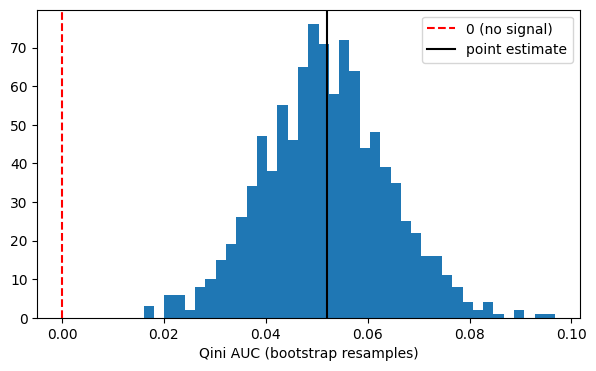

In [ ]:
# Check the boostrap CI

import numpy as np

n_bootstrap = 1000
rng = np.random.default_rng(42)
n = len(y_test)

y_test_arr = np.asarray(y_test)
treatment_test_arr = np.asarray(treatment_test)

bootstrap_scores = []

for _ in range(n_bootstrap):
    idx = rng.integers(0, n, size=n)
    score = qini_auc_score(
        y_true=y_test_arr[idx],
        uplift=uplift_test[idx],
        treatment=treatment_test_arr[idx],
    )
    bootstrap_scores.append(score)

bootstrap_scores = np.array(bootstrap_scores)
ci_lower, ci_upper = np.percentile(bootstrap_scores, [2.5, 97.5])

print(f"Qini AUC (point estimate): {qini_score:.4f}")
print(f"95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Excludes zero: {ci_lower > 0}")

plt.figure(figsize=(7, 4))
plt.hist(bootstrap_scores, bins=40)
plt.axvline(0, color='red', linestyle='--', label='0 (no signal)')
plt.axvline(qini_score, color='black', linestyle='-', label='point estimate')
plt.xlabel('Qini AUC (bootstrap resamples)')
plt.legend()
plt.show()


### Compare naive ranking vs. uplift ranking

In [42]:
from scipy.stats import spearmanr

# same fitted model, two different questions:
# naive: "who's likely to visit if emailed" -> mu1_test alone
# uplift: "who visits BECAUSE they were emailed" -> mu1_test - mu0_test
comparison = test_df.copy()
comparison['naive_score'] = mu1_test
comparison['uplift_score'] = uplift_test

# overall agreement between the two rankings
corr, _ = spearmanr(comparison['naive_score'], comparison['uplift_score'])
print(f"Spearman rank correlation (naive vs uplift): {corr:.3f}")

Spearman rank correlation (naive vs uplift): 0.528


In [43]:
# define a targeting budget and compare who each ranking would select
k_frac = 0.20
n_top = int(len(comparison) * k_frac)

naive_top_idx = comparison['naive_score'].nlargest(n_top).index
uplift_top_idx = comparison['uplift_score'].nlargest(n_top).index

naive_top, uplift_top = set(naive_top_idx), set(uplift_top_idx)
overlap = naive_top & uplift_top
only_naive = naive_top - uplift_top     # "sure things": naive would target, uplift says skip
only_uplift = uplift_top - naive_top    # "persuadables": naive would skip, uplift says target

print(f"Top {k_frac:.0%} targeting overlap: {len(overlap)}/{n_top} ({len(overlap)/n_top:.1%})")
print(f"Naive-only ('sure things'): {len(only_naive)}")
print(f"Uplift-only ('persuadables'): {len(only_uplift)}")


Top 20% targeting overlap: 2430/3840 (63.3%)
Naive-only ('sure things'): 1410
Uplift-only ('persuadables'): 1410


In [44]:
# characterize who's in each disagreement group
profile_cols = ['recency', 'history', 'mens', 'womens', 'newbie', 'zip_code', 'channel']

sure_things = comparison.loc[list(only_naive)]
persuadables = comparison.loc[list(only_uplift)]

print("--- 'Sure things' (naive targets, uplift says skip) ---")
display(sure_things[profile_cols].describe(include='all'))

print("--- 'Persuadables' (naive skips, uplift says target) ---")
display(persuadables[profile_cols].describe(include='all'))

--- 'Sure things' (naive targets, uplift says skip) ---


,recency,history,mens,womens,newbie,zip_code,channel
count,1410.000000,1410.000000,1410.000000,1410.000000,1410.000000,1410,1410
unique,NaN,NaN,NaN,NaN,NaN,3,3
top,NaN,NaN,NaN,NaN,NaN,Rural,Web
freq,NaN,NaN,NaN,NaN,NaN,927,875
mean,3.427660,404.150965,0.466667,0.675887,0.164539,NaN,NaN
std,2.740377,391.448923,0.499065,0.468209,0.370896,NaN,NaN
min,1.000000,29.990000,0.000000,0.000000,0.000000,NaN,NaN
25%,1.000000,186.157500,0.000000,0.000000,0.000000,NaN,NaN
50%,2.000000,323.085000,0.000000,1.000000,0.000000,NaN,NaN
75%,5.000000,448.037500,1.000000,1.000000,0.000000,NaN,NaN


--- 'Persuadables' (naive skips, uplift says target) ---


,recency,history,mens,womens,newbie,zip_code,channel
count,1410.000000,1410.000000,1410.000000,1410.0,1410.000000,1410,1410
unique,NaN,NaN,NaN,NaN,NaN,3,3
top,NaN,NaN,NaN,NaN,NaN,Urban,Phone
freq,NaN,NaN,NaN,NaN,NaN,855,880
mean,4.380142,207.459461,0.150355,1.0,0.297163,NaN,NaN
std,2.935580,191.787341,0.357545,0.0,0.457171,NaN,NaN
min,1.000000,29.990000,0.000000,1.0,0.000000,NaN,NaN
25%,2.000000,68.117500,0.000000,1.0,0.000000,NaN,NaN
50%,4.000000,152.915000,0.000000,1.0,0.000000,NaN,NaN
75%,6.000000,272.555000,0.000000,1.0,1.000000,NaN,NaN


In [45]:
def bootstrap_uplift_ci(group_df, outcome='visit', treatment_col='treatment', n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(group_df)
    y = group_df[outcome].values
    t = group_df[treatment_col].values

    boot_uplifts = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        y_b, t_b = y[idx], t[idx]
        boot_uplifts.append(y_b[t_b == 1].mean() - y_b[t_b == 0].mean())

    return np.array(boot_uplifts)


for name, group in [('Sure things', sure_things), ('Persuadables', persuadables)]:
    n_treated = (group['treatment'] == 1).sum()
    n_control = (group['treatment'] == 0).sum()

    observed_uplift = group.loc[group['treatment'] == 1, 'visit'].mean() - \
                       group.loc[group['treatment'] == 0, 'visit'].mean()

    boot = bootstrap_uplift_ci(group)
    ci_lower, ci_upper = np.percentile(boot, [2.5, 97.5])

    print(f"--- {name} (n_treated={n_treated}, n_control={n_control}) ---")
    print(f"Observed uplift: {observed_uplift:.4f}")
    print(f"95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"Excludes zero: {ci_lower > 0}\n")


--- Sure things (n_treated=929, n_control=481) ---
Observed uplift: 0.0304
95% Bootstrap CI: [-0.0163, 0.0737]
Excludes zero: False

--- Persuadables (n_treated=932, n_control=478) ---
Observed uplift: 0.0510
95% Bootstrap CI: [0.0143, 0.0896]
Excludes zero: True



### Profit Curve

Assumptions:

* Cost per send: $0.00
* Value per visit: $7.16 (data-derived)


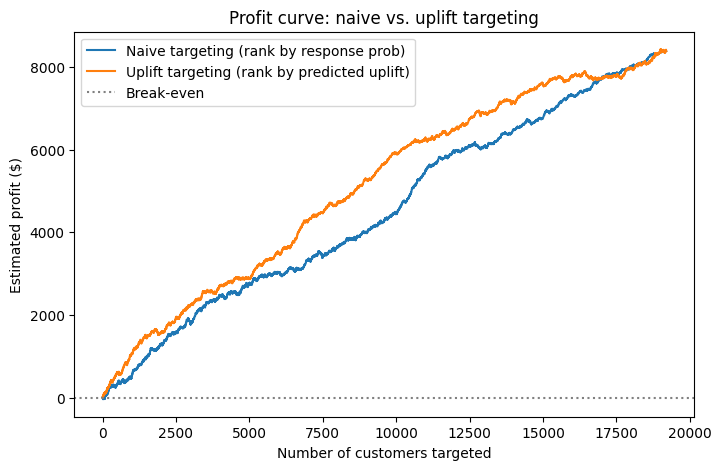

Naive strategy:  best k = 19186, max profit = $8,394.35
Uplift strategy: best k = 19024, max profit = $8,427.80
Gain from uplift targeting: $33.45


In [47]:
from sklift.metrics import uplift_curve
import matplotlib.pyplot as plt

cost_per_send = 0.0
value_per_visit = 7.16

def profit_curve(score, y_true, treatment, value_per_visit, cost_per_send):
    # uplift_curve's y = estimated incremental visits if the top-x ranked
    # customers were all targeted, scaled from the real treated/control gap
    # observed within that top-x slice
    x, incremental_visits = uplift_curve(y_true=y_true, uplift=score, treatment=treatment)
    profit = value_per_visit * incremental_visits - cost_per_send * x
    return x, profit

x_naive, profit_naive = profit_curve(mu1_test, y_test, treatment_test, value_per_visit, cost_per_send)
x_uplift, profit_uplift = profit_curve(uplift_test, y_test, treatment_test, value_per_visit, cost_per_send)

plt.figure(figsize=(8, 5))
plt.plot(x_naive, profit_naive, label='Naive targeting (rank by response prob)')
plt.plot(x_uplift, profit_uplift, label='Uplift targeting (rank by predicted uplift)')
plt.axhline(0, color='gray', linestyle=':', label='Break-even')
plt.xlabel('Number of customers targeted')
plt.ylabel('Estimated profit ($)')
plt.title('Profit curve: naive vs. uplift targeting')
plt.legend()
plt.show()

best_naive_k = x_naive[np.argmax(profit_naive)]
best_naive_profit = profit_naive.max()
best_uplift_k = x_uplift[np.argmax(profit_uplift)]
best_uplift_profit = profit_uplift.max()

print(f"Naive strategy:  best k = {best_naive_k}, max profit = ${best_naive_profit:,.2f}")
print(f"Uplift strategy: best k = {best_uplift_k}, max profit = ${best_uplift_profit:,.2f}")
print(f"Gain from uplift targeting: ${best_uplift_profit - best_naive_profit:,.2f}")
